## Load and prepare final dataframe for model

In [2]:
# Load df_artists and df_songs from CSV with all columns visible in head/sample output.

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df_artists = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists.csv')

print(df_artists.shape)

# Load df_songs from CSV.

df_songs = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_songs.csv')

print(df_songs.shape)


(13655, 44)
(38383, 43)


In [3]:
df_artists.head()

,name,musicbrainz_artist_id,musicbrainz_mbid,spotify_id,performer_pre_normalized,first_top_20_hit_year,first_charting_song_year,last_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,first_song_year,years_active_on_charts,first_charting_song_position,first_charting_song_duration,top_20_hit_song_#_wks_on_chart_any_position,genre_tags_musicbrainz,first_year_on_chart_songs,genre_tags_through_first_top_10_hit,major_genre_categories_through_first_top_10_hit,#_of_major_genre_categories_through_first_top_10_hit,musicbrainz_major_genre_categories,musicbrainz_#_of_genres,spotify_genres,spotify_major_genre_categories,combined_major_genre_categories,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,!!! (chk chk chk),NaN,NaN,NaN,!!! (Chk Chk Chk),NaN,NaN,NaN,NaN,NaN,NaN,2007-2007,0,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"""groove"" holmes",NaN,NaN,NaN,"""Groove"" Holmes",NaN,1966.0,1966.0,NaN,NaN,1966.0,1966-1966,44,11,NaN,NaN,1966.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"""little"" jimmy dickens",NaN,NaN,NaN,"""Little"" Jimmy Dickens",1965.0,1965.0,1965.0,1.0,1.0,1965.0,1965-1965,15,10,NaN,NaN,1965.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,"""pookie"" hudson",232958.0,29dc9009-015f-47c4-bd17-ed2af6d2ae0c,NaN,"""Pookie"" Hudson",NaN,1963.0,1963.0,NaN,NaN,1963.0,1963-1963,96,1,NaN,NaN,1963.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"""weird al"" yankovic",NaN,NaN,NaN,"""Weird Al"" Yankovic",1984.0,1983.0,2014.0,2.0,4.0,1983.0,1983-2014,63,8,NaN,NaN,1983.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


### Create df_artists_final

In [4]:
# Create df_artists_final from df_artists:
# - drops non-feature/identifier columns
# - filters to artists whose first top-20 hit was between 2000 and 2019
# - keeps combined_major_genre_categories, renamed to combined_major_genre_categories_artist

cols_to_drop = [
    'musicbrainz_artist_id', 'musicbrainz_mbid', 'spotify_id',
    'performer_pre_normalized', 'last_charting_song_year', 'first_song_year',
    'years_active_on_charts', 'first_charting_song_position',
    'first_charting_song_duration', 'genre_tags_musicbrainz',
    'first_year_on_chart_songs', 'genre_tags_through_first_top_10_hit',
    'major_genre_categories_through_first_top_10_hit',
    '#_of_major_genre_categories_through_first_top_10_hit',
    'musicbrainz_major_genre_categories', 'musicbrainz_#_of_genres',
    'spotify_genres', 'spotify_major_genre_categories',
]

df_artists_final = (
    df_artists[df_artists['first_top_20_hit_year'].between(2000, 2019)]
    .drop(columns=[c for c in cols_to_drop if c in df_artists.columns])
    .rename(columns={'combined_major_genre_categories': 'combined_major_genre_categories_artist'})
    .reset_index(drop=True)
)

print(df_artists_final.shape)
df_artists_final.head()


(778, 26)


,name,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,combined_major_genre_categories_artist,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,2 chainz,2012.0,2012.0,1.0,9.0,27.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0
1,21 savage,2017.0,2016.0,2.0,15.0,41.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0
2,3 doors down,2000.0,2000.0,1.0,2.0,53.0,"Metal, Pop, Rock","Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
3,3oh!3,2008.0,2008.0,1.0,1.0,37.0,"Electronic/Dance, Hip Hop/Rap, Pop, Punk/Hardc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,5 seconds of summer,2014.0,2014.0,1.0,6.0,20.0,"Pop, Punk/Hardcore",Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,0.000048,1.000000,0.000000,1.555431e-18,NaN,1.0


#### *Only using artist genre tags*

In [5]:
# One-hot encode combined_major_genre_categories_artist into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'artist_genre_', replacing the original column.
# Also adds #_of_genres_artist (count of distinct genres per artist) after artist_genre_unknown.

# Compute genre count before dropping the original column
genre_counts = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .apply(lambda x: len([g for g in x.split(', ') if g.strip()]) if x else 0)
)

artist_genre_dummies = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='artist_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
artist_genre_dummies = artist_genre_dummies.loc[:, artist_genre_dummies.columns != 'artist_genre_']

# Insert genre columns where combined_major_genre_categories_artist was, then drop original
insert_at = df_artists_final.columns.get_loc('combined_major_genre_categories_artist')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    artist_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

# Add binary flag for artists with no genre data — inserted after last genre column
all_genre_cols = [c for c in df_artists_final.columns if c.startswith(('artist_genre_', 'song_genre_'))]
last_genre_idx = df_artists_final.columns.get_loc(all_genre_cols[-1])
df_artists_final.insert(last_genre_idx + 1, 'artist_genre_unknown', (df_artists_final[all_genre_cols].sum(axis=1) == 0).astype(int))

# Insert #_of_genres_artist after artist_genre_unknown
unknown_idx = df_artists_final.columns.get_loc('artist_genre_unknown')
df_artists_final.insert(unknown_idx + 1, '#_of_genres_artist', genre_counts)

print("Artist genre columns added:", artist_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


Artist genre columns added: ['artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music']
df_artists_final shape: (778, 45)


In [6]:
# Drop rows with null top_20_hitmaker (artists with no verified top-20 songs)
# and any duplicate rows, then confirm shape and class balance.

df_artists_final = (
    df_artists_final
    .dropna(subset=['top_20_hitmaker'])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_artists_final.shape)
print()
print(df_artists_final['top_20_hitmaker'].value_counts())


(759, 45)

top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64


In [7]:
# Drop name column, cast bool genre columns to int (0/1) in df_artists_final.

genre_cols = [c for c in df_artists_final.columns if c.startswith('genre_')]

df_artists_final = df_artists_final.drop(columns=['name'])
df_artists_final[genre_cols] = df_artists_final[genre_cols].astype(int)

print(df_artists_final.shape)
print(df_artists_final[genre_cols].dtypes.unique())


(759, 44)
[]


#### *Check this next cell for decisions regarding null values*

In [8]:
# Impute missing values in df_artists_final and drop Spotify audio features:
# - Network metrics → fill with 0 (no collaboration data = no centrality)
# - Weeks on chart → fill with median
# - Spotify audio features → dropped entirely

network_metric_cols = [
    'degree_centrality', 'harmonic_closeness', 'betweenness_centrality',
    'eigenvector_centrality', 'power'
]
for col in network_metric_cols:
    if col in df_artists_final.columns:
        df_artists_final[col] = df_artists_final[col].fillna(0)

wks_col = 'top_20_hit_song_#_wks_on_chart_any_position'
if wks_col in df_artists_final.columns:
    median_wks = df_artists_final[wks_col].median()
    df_artists_final[wks_col] = df_artists_final[wks_col].fillna(median_wks)
    print(f"Weeks on chart median impute value: {median_wks}")

spotify_audio_cols = [
    'first_top_20_song_duration_ms', 'first_top_20_song_acousticness',
    'first_top_20_song_danceability', 'first_top_20_song_energy',
    'first_top_20_song_instrumentalness', 'first_top_20_song_liveness',
    'first_top_20_song_loudness', 'first_top_20_song_speechiness',
    'first_top_20_song_tempo', 'first_top_20_song_valence',
    'first_top_20_song_mode', 'first_top_20_song_key',
    'first_top_20_song_explicit', 'first_top_20_song_popularity',
]
df_artists_final = df_artists_final.drop(
    columns=[c for c in spotify_audio_cols if c in df_artists_final.columns]
)

print("Imputation complete. Spotify audio features dropped.")
print(f"df_artists_final shape: {df_artists_final.shape}")
print(df_artists_final.isnull().sum()[df_artists_final.isnull().sum() > 0])


Weeks on chart median impute value: 26.0
Imputation complete. Spotify audio features dropped.
df_artists_final shape: (759, 32)
first_top_20_song_major_genres                  391
degree_centrality_top20_rolling5                206
harmonic_closeness_centrality_top20_rolling5    206
betweenness_centrality_top20_rolling5           206
eigenvector_centrality_top20_rolling5           206
power_of_connected_artists_top20_rolling5       246
dtype: int64


In [10]:
# Fill null network metric columns with 0 (no collaboration data = no centrality)
# degree_centrality and power dropped due to collinearity — not used in model
df_artists_final = df_artists_final.drop(columns=[
    'degree_centrality_top20_rolling5',
    'power_of_connected_artists_top20_rolling5',
], errors='ignore')

network_cols = [
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
]
df_artists_final[network_cols] = df_artists_final[network_cols].fillna(0)
print(df_artists_final[network_cols].isnull().sum())


harmonic_closeness_centrality_top20_rolling5    0
betweenness_centrality_top20_rolling5           0
eigenvector_centrality_top20_rolling5           0
dtype: int64


In [11]:
df_artists_final.head()

,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,#_of_genres_artist,first_top_20_song_major_genres,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,top_20_hitmaker
0,2012.0,2012.0,1.0,9.0,27.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,NaN,5314.363492,0.010130,1.510211e-01,1.0
1,2017.0,2016.0,2.0,15.0,41.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,NaN,5233.436039,0.001326,7.977090e-02,1.0
2,2000.0,2000.0,1.0,2.0,53.0,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,0,3,"Blues, Metal, Rock",0.000000,0.000000,0.000000e+00,1.0
3,2008.0,2008.0,1.0,1.0,37.0,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,True,False,0,5,NaN,0.000000,0.000000,0.000000e+00,1.0
4,2014.0,2014.0,1.0,6.0,20.0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,0,2,Pop,1.000000,0.000000,1.555431e-18,1.0


## Model

In [12]:
# Drop columns not used as model features
cols_to_drop = ['first_top_20_song_major_genres', 'first_top_20_hit_year', 'first_charting_song_year']
df_artists_final = df_artists_final.drop(columns=[c for c in cols_to_drop if c in df_artists_final.columns])
print(df_artists_final.shape)


(759, 27)


In [13]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")


X shape: (759, 26)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [14]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (607, 26), Test: (152, 26)

Train class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Test class balance:
top_20_hitmaker
0.0    0.566
1.0    0.434
Name: proportion, dtype: float64


In [15]:
# Scale features for models sensitive to feature magnitude (Logistic Regression, SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Scaling complete.
X_train_scaled shape: (607, 26)


In [17]:
# Evaluate models using 5-fold cross-validation on training set only.
# Logistic Regression and SVM wrapped in pipelines with StandardScaler to ensure convergence.

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = {
    'Dummy':               DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
    'SVM':                 Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


                     Accuracy  Precision  Recall     F1  ROC-AUC (CV)  \
Model                                                                   
Dummy                   0.503      0.421   0.405  0.413         0.491   
Logistic Regression     0.677      0.658   0.534  0.583         0.714   
SVM                     0.674      0.661   0.508  0.572         0.730   
Random Forest           0.674      0.630   0.595  0.612         0.740   
XGBoost                 0.639      0.589   0.550  0.567         0.703   

                     ROC-AUC (Train)  Overfit Gap  
Model                                              
Dummy                          0.490       -0.001  
Logistic Regression            0.771        0.056  
SVM                            0.865        0.135  
Random Forest                  0.990        0.250  
XGBoost                        0.996        0.294  


In [18]:
# Lightweight regularization pass for Random Forest and XGBoost.
# Goal: close overfit gaps before committing to full hyperparameter search.
# 20 iterations each, focused on depth and leaf/child weight controls.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# --- Random Forest ---
rf_reg_grid = {
    'max_depth':        randint(3, 8),
    'min_samples_leaf': randint(10, 50),
    'min_samples_split':randint(10, 50),
    'max_features':     ['sqrt', 'log2', 0.5],
}

rf_reg_search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    rf_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_reg_search.fit(X_train, y_train)

# --- XGBoost ---
xgb_reg_grid = {
    'max_depth':        randint(2, 5),
    'min_child_weight': randint(10, 30),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_reg_search = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    xgb_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_reg_search.fit(X_train, y_train)

# --- Report ---
from sklearn.model_selection import cross_validate

print("\n" + "=" * 50)
for name, search in [('Random Forest', rf_reg_search), ('XGBoost', xgb_reg_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest
  Best params:     {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 11, 'min_samples_split': 33}
  ROC-AUC (CV):    0.753 ± 0.038
  ROC-AUC (Train): 0.822
  Overfit Gap:     0.069

XGBoost
  Best params:     {'colsample_bytree': np.float64(0.7933755828319241), 'max_depth': 2, 'min_child_weight': 22, 'reg_alpha': np.float64(1.7046211248738132), 'reg_lambda': np.float64(11.021969807540398), 'subsample': np.float64(0.6298202574719083)}
  ROC-AUC (CV):    0.752 ± 0.033
  ROC-AUC (Train): 0.782
  Overfit Gap:     0.031



In [19]:
# Full hyperparameter search for Random Forest and XGBoost.
# 100 iterations each, 5-fold CV, optimizing ROC-AUC.
# Builds on regularization pass — search ranges informed by best params found above.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# --- Random Forest ---
rf_grid = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(3, 8),
    'min_samples_leaf':  randint(5, 50),
    'min_samples_split': randint(5, 50),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

# --- XGBoost ---
xgb_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.1),
    'min_child_weight':  randint(10, 30),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_alpha':         uniform(1, 5),
    'reg_lambda':        uniform(3, 10),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

# --- Report ---
print("\n" + "=" * 50)
for name, search in [('Random Forest', rf_search), ('XGBoost', xgb_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Random Forest
  Best params:     {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 28, 'n_estimators': 393}
  ROC-AUC (CV):    0.754 ± 0.038
  ROC-AUC (Train): 0.840
  Overfit Gap:     0.086

XGBoost
  Best params:     {'colsample_bytree': np.float64(0.518341601445299), 'learning_rate': np.float64(0.035243694434402076), 'max_depth': 4, 'min_child_weight': 12, 'n_estimators': 210, 'reg_alpha': np.float64(5.222203363168144), 'reg_lambda': np.float64(10.496162320085874), 'subsample': np.float64(0.6121888610934376)}
  ROC-AUC (CV):    0.753 ± 0.037
  ROC-AUC (Train): 0.796
  Overfit Gap:     0.043



In [20]:
# Hyperparameter tuning for Logistic Regression and SVM.
# 100 iterations each, 5-fold CV, optimizing ROC-AUC.
# Both wrapped in StandardScaler pipelines.

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from scipy.stats import uniform, loguniform

# --- Logistic Regression ---
lr_grid = {
    'clf__C':       loguniform(0.001, 100),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear', 'saga'],
}

lr_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
    lr_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
lr_search.fit(X_train, y_train)

# --- SVM ---
svm_grid = {
    'clf__C':     loguniform(0.01, 100),
    'clf__gamma': ['scale', 'auto'],
    'clf__kernel':['rbf', 'linear'],
}

svm_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    svm_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
svm_search.fit(X_train, y_train)

# --- Report ---
print("\n" + "=" * 50)
for name, search in [('Logistic Regression', lr_search), ('SVM', svm_search)]:
    cv = cross_validate(search.best_estimator_, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print()


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Logistic Regression
  Best params:     {'clf__C': np.float64(0.0014857392806279248), 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
  ROC-AUC (CV):    0.724 ± 0.016
  ROC-AUC (Train): 0.749
  Overfit Gap:     0.025

SVM
  Best params:     {'clf__C': np.float64(0.5342937261279778), 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
  ROC-AUC (CV):    0.738 ± 0.015
  ROC-AUC (Train): 0.842
  Overfit Gap:     0.104



In [21]:
# Final evaluation of all four tuned models on the held-out test set.
# Reports ROC-AUC, log loss, accuracy, precision, recall, F1, and overfit gap.

from sklearn.metrics import (roc_auc_score, log_loss, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
from sklearn.model_selection import cross_validate

models_final = {
    'Logistic Regression': lr_search.best_estimator_,
    'SVM':                 svm_search.best_estimator_,
    'Random Forest':       rf_search.best_estimator_,
    'XGBoost':             xgb_search.best_estimator_,
}

summary = []
for name, model in models_final.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv = cross_validate(model, X_train, y_train, cv=5,
                        scoring='roc_auc', return_train_score=True)
    print(f"{'='*52}")
    print(f"{name}")
    print(f"{'='*52}")
    print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
    print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
    print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
    print(f"  Log Loss (Test): {log_loss(y_test, y_proba):.3f}")
    print(f"  Accuracy (Test): {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision (Test):{precision_score(y_test, y_pred):.3f}")
    print(f"  Recall (Test):   {recall_score(y_test, y_pred):.3f}")
    print(f"  F1 (Test):       {f1_score(y_test, y_pred):.3f}")
    print(f"\n{classification_report(y_test, y_pred)}\n")
    summary.append({
        'Model':           name,
        'ROC-AUC (CV)':    cv['test_score'].mean(),
        'ROC-AUC (Train)': cv['train_score'].mean(),
        'ROC-AUC (Test)':  roc_auc_score(y_test, y_proba),
        'Overfit Gap':     cv['train_score'].mean() - cv['test_score'].mean(),
        'Log Loss':        log_loss(y_test, y_proba),
        'Accuracy':        accuracy_score(y_test, y_pred),
        'Precision':       precision_score(y_test, y_pred),
        'Recall':          recall_score(y_test, y_pred),
        'F1':              f1_score(y_test, y_pred),
    })

print("=" * 52)
print("FINAL COMPARISON (Test Set)")
print("=" * 52)
df_final = pd.DataFrame(summary).set_index('Model').round(3)
print(df_final.to_string())


Logistic Regression
  ROC-AUC (CV):    0.724 ± 0.016
  ROC-AUC (Train): 0.749
  ROC-AUC (Test):  0.734
  Overfit Gap:     0.025
  Log Loss (Test): 0.638
  Accuracy (Test): 0.678
  Precision (Test):0.639
  Recall (Test):   0.591
  F1 (Test):       0.614

              precision    recall  f1-score   support

         0.0       0.70      0.74      0.72        86
         1.0       0.64      0.59      0.61        66

    accuracy                           0.68       152
   macro avg       0.67      0.67      0.67       152
weighted avg       0.68      0.68      0.68       152


SVM
  ROC-AUC (CV):    0.738 ± 0.015
  ROC-AUC (Train): 0.842
  ROC-AUC (Test):  0.735
  Overfit Gap:     0.104
  Log Loss (Test): 0.575
  Accuracy (Test): 0.704
  Precision (Test):0.756
  Recall (Test):   0.470
  F1 (Test):       0.579

              precision    recall  f1-score   support

         0.0       0.68      0.88      0.77        86
         1.0       0.76      0.47      0.58        66

    accuracy    

XGBoost — Final Model Evaluation
  ROC-AUC (Test):   0.761
  Log Loss (Test):  0.575
  Brier Score:      0.196
  Accuracy:         0.711
  Precision:        0.683
  Recall:           0.621
  F1:               0.651

              precision    recall  f1-score   support

         0.0       0.73      0.78      0.75        86
         1.0       0.68      0.62      0.65        66

    accuracy                           0.71       152
   macro avg       0.71      0.70      0.70       152
weighted avg       0.71      0.71      0.71       152



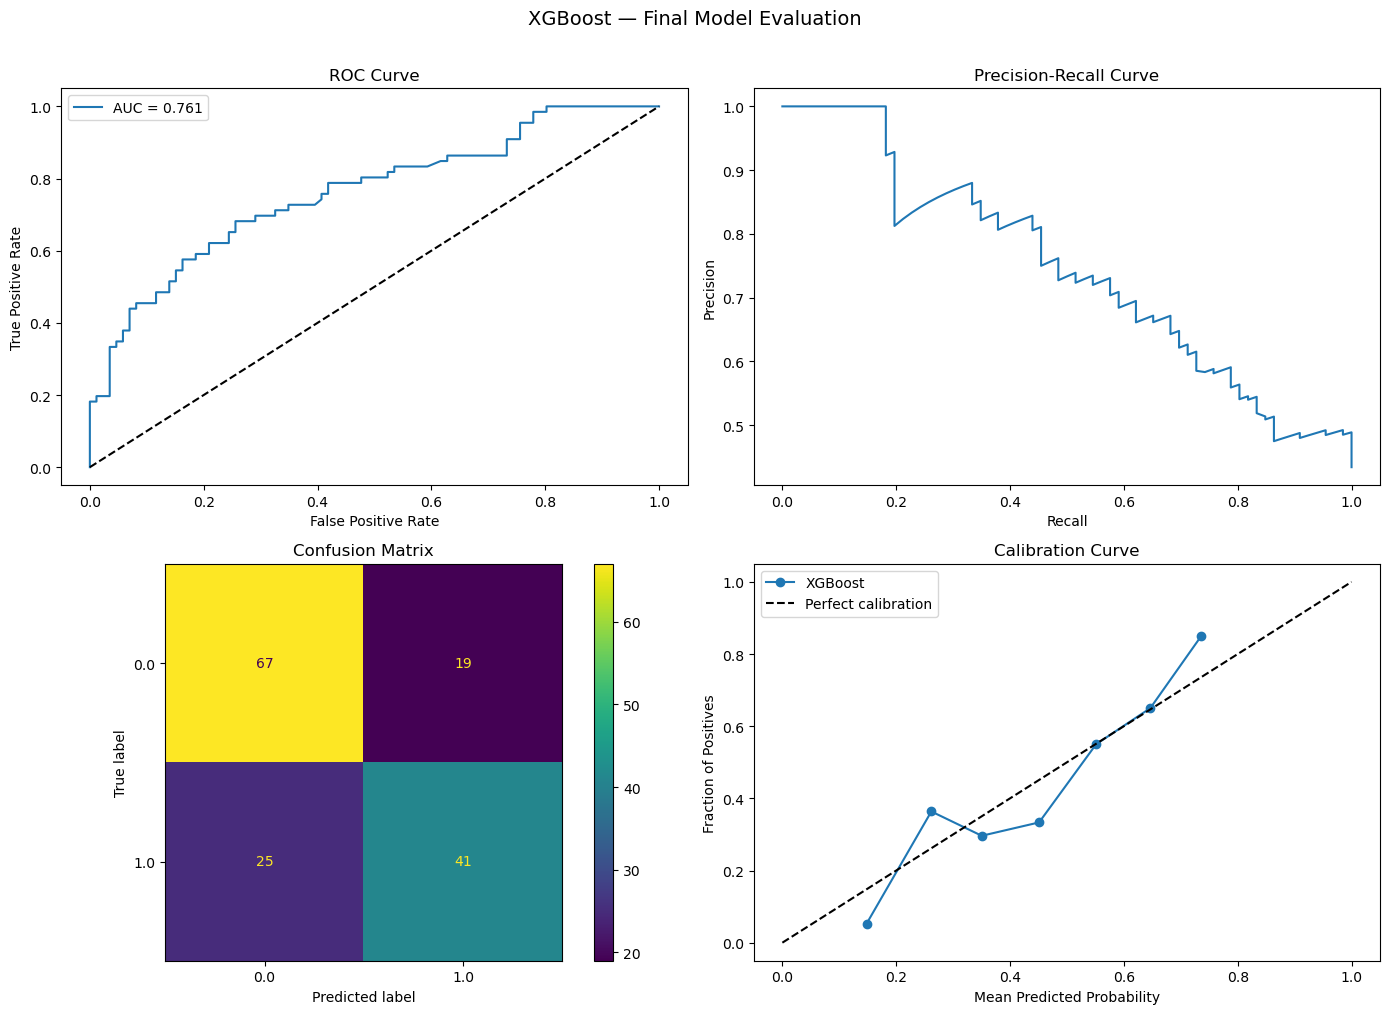


Feature Importance (mean absolute SHAP):
                                     feature  mean_abs_shap
#_of_charting_songs_through_first_top_20_hit       0.489651
       betweenness_centrality_top20_rolling5       0.207102
       eigenvector_centrality_top20_rolling5       0.169489
                            artist_genre_Pop       0.147940
                          #_of_genres_artist       0.143417
                    artist_genre_Hip Hop/Rap       0.093943
 top_20_hit_song_#_wks_on_chart_any_position       0.070579
harmonic_closeness_centrality_top20_rolling5       0.053298
              years_through_first_top_20_hit       0.035532
                  artist_genre_R&B/Soul/Funk       0.030232
                        artist_genre_unknown       0.005492
                           artist_genre_Rock       0.002585
               artist_genre_Reggae/Caribbean       0.000000
                          artist_genre_Blues       0.000000
                      artist_genre_Classical       0.00000

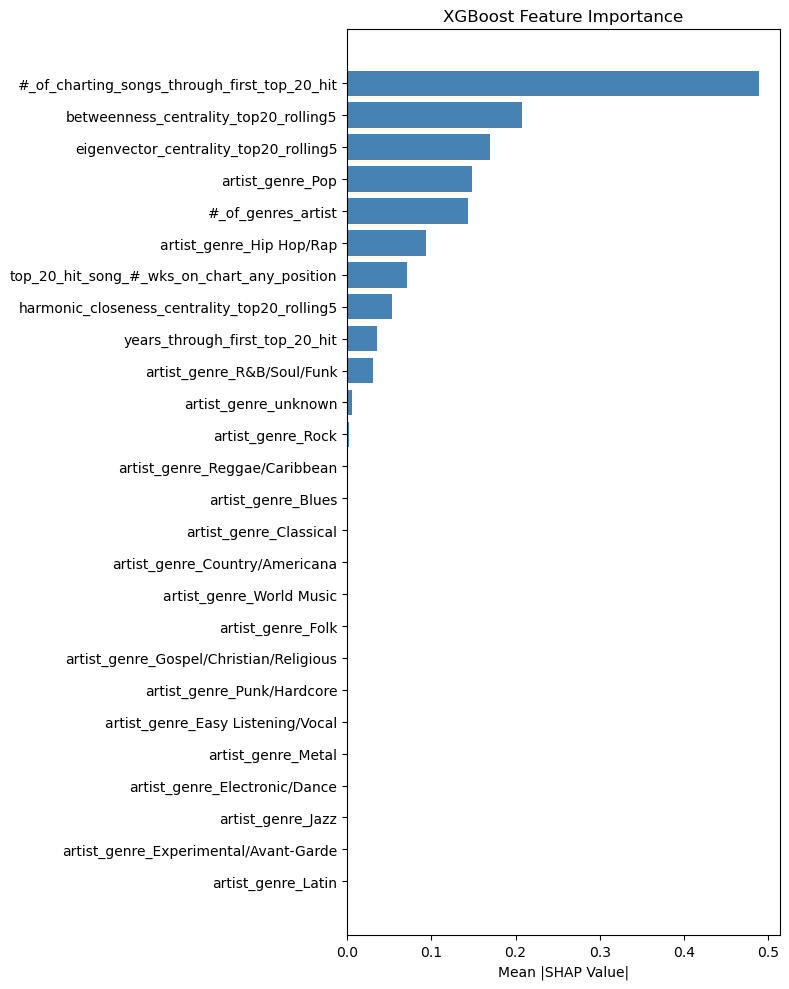

In [22]:
# Deep evaluation of tuned XGBoost as final model.
# Includes ROC curve, confusion matrix, precision-recall curve,
# SHAP feature importance, and calibration curve.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve

best_xgb = xgb_search.best_estimator_
y_pred  = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# --- Summary stats ---
print("=" * 52)
print("XGBoost — Final Model Evaluation")
print("=" * 52)
print(f"  ROC-AUC (Test):   {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Log Loss (Test):  {log_loss(y_test, y_proba):.3f}")
print(f"  Brier Score:      {brier_score_loss(y_test, y_proba):.3f}")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:        {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:           {recall_score(y_test, y_pred):.3f}")
print(f"  F1:               {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred))

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='XGBoost')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].legend()

plt.suptitle('XGBoost — Final Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- SHAP feature importance ---
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap_importance = (
    pd.DataFrame({
        'feature': X_test.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print("\nFeature Importance (mean absolute SHAP):")
print(shap_importance.to_string(index=False))

plt.figure(figsize=(8, 10))
plt.barh(shap_importance['feature'][::-1], shap_importance['mean_abs_shap'][::-1], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


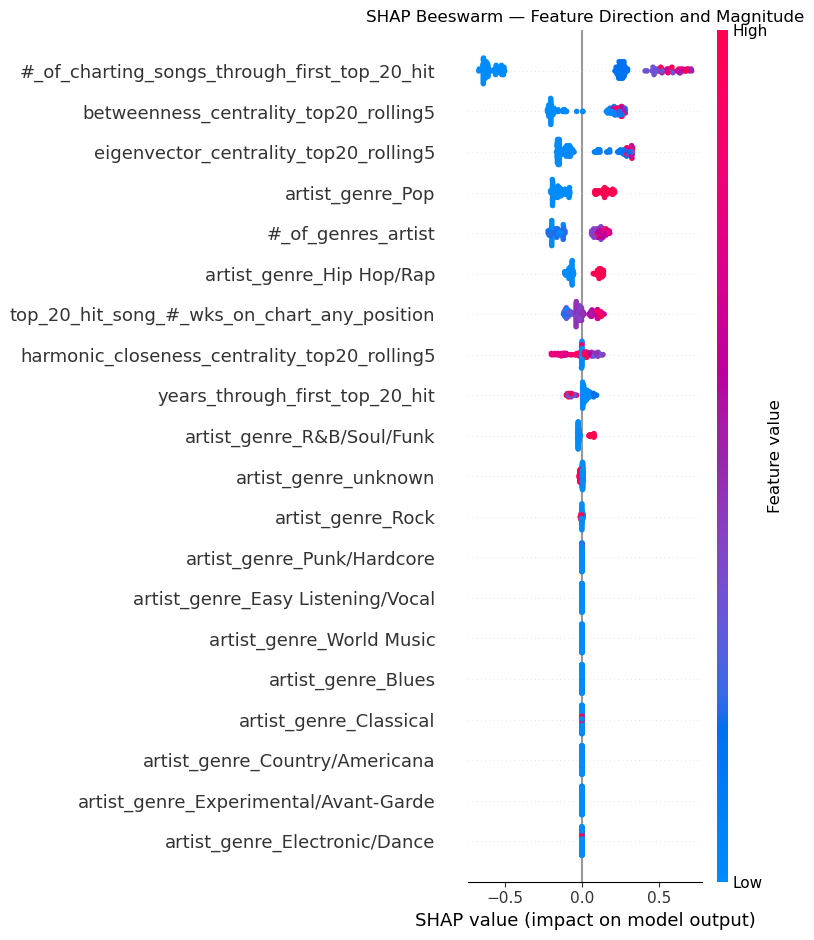

In [23]:
# SHAP beeswarm plot showing both magnitude and direction of feature contributions.
# Red = high feature value, Blue = low feature value.
# X-axis position shows whether the feature pushes toward hitmaker (positive) or one-hit wonder (negative).

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Feature Direction and Magnitude')
plt.tight_layout()
plt.show()


#### Now checking which features contribute meaningful signal.

In [25]:
# Check feature contribution by comparing full model AUC to AUC with each feature dropped one at a time.
# Features where dropping them doesn't hurt (or helps) AUC are candidates for removal.

results_ablation = []

for col in X_train.columns:
    X_tr = X_train.drop(columns=[col])
    X_te = X_test.drop(columns=[col])

    model = XGBClassifier(
        random_state=42, eval_metric='logloss',
        **xgb_search.best_params_
    )
    cv = cross_validate(model, X_tr, y_train, cv=5,
                        scoring='roc_auc', return_train_score=False)
    model.fit(X_tr, y_train)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])

    results_ablation.append({
        'feature':        col,
        'CV AUC (drop)':  cv['test_score'].mean(),
        'Test AUC (drop)': test_auc,
        'CV AUC delta':   cv['test_score'].mean() - 0.753,
        'Test AUC delta': test_auc - 0.761,
    })

df_ablation = (
    pd.DataFrame(results_ablation)
    .sort_values('CV AUC delta', ascending=False)
    .reset_index(drop=True)
)

print("Positive delta = dropping the feature HELPS. Negative = it HURTS.")
print(df_ablation.to_string(index=False))


Positive delta = dropping the feature HELPS. Negative = it HURTS.
                                     feature  CV AUC (drop)  Test AUC (drop)  CV AUC delta  Test AUC delta
 top_20_hit_song_#_wks_on_chart_any_position       0.754393         0.758633      0.001393       -0.002367
       betweenness_centrality_top20_rolling5       0.753403         0.764887      0.000403        0.003887
                           artist_genre_Folk       0.753358         0.763302      0.000358        0.002302
                          artist_genre_Blues       0.753358         0.763302      0.000358        0.002302
                      artist_genre_Classical       0.753358         0.763302      0.000358        0.002302
              artist_genre_Country/Americana       0.753358         0.763302      0.000358        0.002302
           artist_genre_Easy Listening/Vocal       0.753358         0.763302      0.000358        0.002302
               artist_genre_Electronic/Dance       0.753358         0.763302  

#### Dropping low importance features and running the model again with fewer features.

In [28]:
# Retrain XGBoost keeping only clear keeper and borderline features.
# Uses same best params from tuning.

features_to_keep = [
    '#_of_charting_songs_through_first_top_20_hit',
    'artist_genre_Hip Hop/Rap',
    'artist_genre_Pop',
    'years_through_first_top_20_hit',
    'artist_genre_Rock',
    '#_of_genres_artist',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_unknown',
]

X_train_trim = X_train[features_to_keep]
X_test_trim  = X_test[features_to_keep]

model_trim = XGBClassifier(
    random_state=42, eval_metric='logloss',
    **xgb_search.best_params_
)

cv = cross_validate(model_trim, X_train_trim, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
model_trim.fit(X_train_trim, y_train)
y_proba_trim = model_trim.predict_proba(X_test_trim)[:, 1]

print("Trimmed model (keepers + borderline):")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nFull model (reference):")
print(f"  ROC-AUC (CV):    0.753")
print(f"  ROC-AUC (Test):  0.761")


Trimmed model (keepers + borderline):
  ROC-AUC (CV):    0.758 ± 0.035
  ROC-AUC (Train): 0.774
  ROC-AUC (Test):  0.778
  Overfit Gap:     0.016

Full model (reference):
  ROC-AUC (CV):    0.753
  ROC-AUC (Test):  0.761


In [27]:
# Retrain XGBoost dropping only the zero-contribution genre columns.
# Keeps all other features including borderline ones.

zero_contrib_genres = [
    'artist_genre_Folk',
    'artist_genre_Blues',
    'artist_genre_Classical',
    'artist_genre_Country/Americana',
    'artist_genre_Easy Listening/Vocal',
    'artist_genre_Electronic/Dance',
    'artist_genre_Experimental/Avant-Garde',
    'artist_genre_Gospel/Christian/Religious',
    'artist_genre_Metal',
    'artist_genre_Latin',
    'artist_genre_Jazz',
    'artist_genre_Reggae/Caribbean',
    'artist_genre_World Music',
]

X_train_trim2 = X_train.drop(columns=[c for c in zero_contrib_genres if c in X_train.columns])
X_test_trim2  = X_test.drop(columns=[c for c in zero_contrib_genres if c in X_test.columns])

model_trim2 = XGBClassifier(
    random_state=42, eval_metric='logloss',
    **xgb_search.best_params_
)

cv = cross_validate(model_trim2, X_train_trim2, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
model_trim2.fit(X_train_trim2, y_train)
y_proba_trim2 = model_trim2.predict_proba(X_test_trim2)[:, 1]

print("Conservative trim (zero-contrib genres dropped):")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim2):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nFull model (reference):")
print(f"  ROC-AUC (CV):    0.753")
print(f"  ROC-AUC (Test):  0.761")


Conservative trim (zero-contrib genres dropped):
  ROC-AUC (CV):    0.753 ± 0.041
  ROC-AUC (Train): 0.793
  ROC-AUC (Test):  0.756
  Overfit Gap:     0.040

Full model (reference):
  ROC-AUC (CV):    0.753
  ROC-AUC (Test):  0.761


In [29]:
# Re-tune XGBoost on the conservatively trimmed feature set (zero-contrib genres dropped).
# 100 iterations, 5-fold CV, optimizing ROC-AUC.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

xgb_grid_trim = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(2, 5),
    'learning_rate':     uniform(0.01, 0.1),
    'min_child_weight':  randint(10, 30),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'reg_alpha':         uniform(1, 5),
    'reg_lambda':        uniform(3, 10),
}

xgb_trim_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid_trim,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_trim_search.fit(X_train_trim2, y_train)

cv = cross_validate(xgb_trim_search.best_estimator_, X_train_trim2, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
y_proba_trim_tuned = xgb_trim_search.best_estimator_.predict_proba(X_test_trim2)[:, 1]

print("Re-tuned trimmed model:")
print(f"  Best params:     {xgb_trim_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim_tuned):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nFull model (reference):")
print(f"  ROC-AUC (CV):    0.753")
print(f"  ROC-AUC (Test):  0.761")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Re-tuned trimmed model:
  Best params:     {'colsample_bytree': np.float64(0.6119245329531603), 'learning_rate': np.float64(0.09217906368444492), 'max_depth': 3, 'min_child_weight': 19, 'n_estimators': 121, 'reg_alpha': np.float64(1.443512668785278), 'reg_lambda': np.float64(4.206358711006008), 'subsample': np.float64(0.7843115072130903)}
  ROC-AUC (CV):    0.753 ± 0.028
  ROC-AUC (Train): 0.812
  ROC-AUC (Test):  0.774
  Overfit Gap:     0.059

Full model (reference):
  ROC-AUC (CV):    0.753
  ROC-AUC (Test):  0.761
